# Financial Machine Learning

June 2025 \\
FInancial AI Convergece \\
Chung-Ang University Business School



## F1~ F4 전처리 코드입니다.

In [1]:
import pandas as pd

# 1. CSV 파일 불러오기
ica_df = pd.read_csv("ica_features_for_model.csv")
stocks_df = pd.read_csv("korean_stocks_with_indicators.csv")

# 2. 두 데이터프레임 병합 (기준: Date, Stock_Name)
merged_df = pd.merge(ica_df, stocks_df, on=['Date', 'Stock_Name'], how='inner')

# 3. Date를 인덱스로 설정
merged_df.set_index('Date', inplace=True)

# 4. 종목별로 분할하고, 컬럼명을 "종목명_원래컬럼명" 형식으로 변경한 후 열 방향으로 결합
unique_stocks = merged_df['Stock_Name'].unique()
columns_to_pivot = merged_df.drop(columns=['Stock_Name'])  # Stock_Name 제외

reformatted_df = pd.DataFrame()

for stock in unique_stocks:
    stock_df = merged_df[merged_df['Stock_Name'] == stock].drop(columns=['Stock_Name'])
    stock_df = stock_df.add_prefix(f"{stock}_")  # 컬럼명 앞에 종목명 추가
    reformatted_df = pd.concat([reformatted_df, stock_df], axis=1)

# 5. 인덱스 초기화 (Date 다시 컬럼으로)
reformatted_df.reset_index(inplace=True)

# 6. 결과 출력 또는 저장
print(reformatted_df.head())
print(reformatted_df.shape)




         Date  삼성전자_Return  삼성전자_CommonIC_Price_0  삼성전자_CommonIC_Price_1  \
0  2022-02-04     0.176472               0.438168               2.530607   
1  2022-02-07    -0.262805              -0.283398              -1.184293   
2  2022-02-08     0.000000              -0.283398              -1.184293   
3  2022-02-09     0.000000              -0.052010               0.548078   
4  2022-02-21     0.000000              -0.877335               0.186133   

   삼성전자_CommonIC_Price_2  삼성전자_CommonIC_Price_3  삼성전자_CommonIC_Price_4  \
0              -0.709664               0.563866              -0.946874   
1              -0.585963              -0.169167              -1.491954   
2              -0.585963              -0.169167              -1.491954   
3              -0.297693              -0.030064              -0.807769   
4               0.893952               0.807701               1.288570   

   삼성전자_CommonIC_Price_5  삼성전자_CommonIC_Price_6  삼성전자_CommonIC_Price_7  ...  \
0               0.8

/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_40942/705068795.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  reformatted_df.reset_index(inplace=True)


In [2]:
technical_indicators = ['MACD', 'RSI', 'OBV']
indicator_columns = []

# 종목별로 기술적 지표 컬럼만 골라서 리스트에 추가
for stock in unique_stocks:
    for indicator in technical_indicators:
        col_name = f"{stock}_{indicator}"
        if col_name in reformatted_df.columns:
            indicator_columns.append(col_name)

# 8. f1 데이터프레임 생성 (Date 포함, 총 91개 컬럼)
f1_df = reformatted_df[['Date'] + indicator_columns]

# 9. 결과 출력
print(f1_df.head())
print(f1_df.shape)




         Date    삼성전자_MACD   삼성전자_RSI    삼성전자_OBV  LG에너지솔루션_MACD  \
0  2022-02-04  -951.997642  27.928037  69546338.0     484.695378   
1  2022-02-07 -1002.120746  27.928037  55305500.0    2888.149344   
2  2022-02-08 -1029.970805  29.523899  55305500.0    4278.663518   
3  2022-02-09 -1040.053093  28.155375  55305500.0    3420.552965   
4  2022-02-21  -446.819028  65.306142  61103413.0   -7022.584212   

   LG에너지솔루션_RSI  LG에너지솔루션_OBV   현대모비스_MACD  현대모비스_RSI  현대모비스_OBV  ...  \
0      0.000000      447658.0 -5333.609681  16.128971 -2801969.0  ...   
1      0.000000     2358834.0 -5435.250491  18.749938 -2989248.0  ...   
2      0.000000     2358834.0 -5452.943427  17.721453 -2989248.0  ...   
3      0.000000      288130.0 -5404.663609  20.289799 -2989248.0  ...   
4     40.405904    -4795461.0 -4377.277274  52.727254 -2998053.0  ...   

       KT_OBV  하나금융지주_MACD  하나금융지주_RSI  하나금융지주_OBV   신한지주_MACD   신한지주_RSI  \
0  48433776.0   467.034007   47.598249  45278716.0  331.208899  47.499958  

In [3]:
# 종목별 ICA 피처 1개(CommonIC_Price_0)씩 추가하여 f2 생성
ica_feature = 'CommonIC_Price_0'
ica_feature_columns = []

for stock in unique_stocks:
    col_name = f"{stock}_{ica_feature}"
    if col_name in reformatted_df.columns:
        ica_feature_columns.append(col_name)

f2_df = f1_df.merge(reformatted_df[['Date'] + ica_feature_columns], on='Date', how='left')


print(f2_df.head())
print(f2_df.shape)

         Date    삼성전자_MACD   삼성전자_RSI    삼성전자_OBV  LG에너지솔루션_MACD  \
0  2022-02-04  -951.997642  27.928037  69546338.0     484.695378   
1  2022-02-07 -1002.120746  27.928037  55305500.0    2888.149344   
2  2022-02-08 -1029.970805  29.523899  55305500.0    4278.663518   
3  2022-02-09 -1040.053093  28.155375  55305500.0    3420.552965   
4  2022-02-21  -446.819028  65.306142  61103413.0   -7022.584212   

   LG에너지솔루션_RSI  LG에너지솔루션_OBV   현대모비스_MACD  현대모비스_RSI  현대모비스_OBV  ...  \
0      0.000000      447658.0 -5333.609681  16.128971 -2801969.0  ...   
1      0.000000     2358834.0 -5435.250491  18.749938 -2989248.0  ...   
2      0.000000     2358834.0 -5452.943427  17.721453 -2989248.0  ...   
3      0.000000      288130.0 -5404.663609  20.289799 -2989248.0  ...   
4     40.405904    -4795461.0 -4377.277274  52.727254 -2998053.0  ...   

   롯데케미칼_CommonIC_Price_0  LG생활건강_CommonIC_Price_0  고려아연_CommonIC_Price_0  \
0                0.438168                 0.438168               0.438168  

In [4]:
price_lag_columns = []
return_lag_columns = []

for stock in unique_stocks:
    price_col = f"{stock}_Close"
    return_col = f"{stock}_Return"

    if price_col in reformatted_df.columns:
        lag_price_col = f"{stock}_Price_t-1"
        reformatted_df[lag_price_col] = reformatted_df[price_col].shift(1)
        price_lag_columns.append(lag_price_col)

    if return_col in reformatted_df.columns:
        lag_return_col = f"{stock}_Return_t-1"
        reformatted_df[lag_return_col] = reformatted_df[return_col].shift(1)
        return_lag_columns.append(lag_return_col)

# f3 = f2 + lagged features
f3_df = f2_df.merge(reformatted_df[['Date'] + price_lag_columns + return_lag_columns], on='Date', how='left')

print(f3_df.head())
print(f3_df.shape)

         Date    삼성전자_MACD   삼성전자_RSI    삼성전자_OBV  LG에너지솔루션_MACD  \
0  2022-02-04  -951.997642  27.928037  69546338.0     484.695378   
1  2022-02-07 -1002.120746  27.928037  55305500.0    2888.149344   
2  2022-02-08 -1029.970805  29.523899  55305500.0    4278.663518   
3  2022-02-09 -1040.053093  28.155375  55305500.0    3420.552965   
4  2022-02-21  -446.819028  65.306142  61103413.0   -7022.584212   

   LG에너지솔루션_RSI  LG에너지솔루션_OBV   현대모비스_MACD  현대모비스_RSI  현대모비스_OBV  ...  \
0      0.000000      447658.0 -5333.609681  16.128971 -2801969.0  ...   
1      0.000000     2358834.0 -5435.250491  18.749938 -2989248.0  ...   
2      0.000000     2358834.0 -5452.943427  17.721453 -2989248.0  ...   
3      0.000000      288130.0 -5404.663609  20.289799 -2989248.0  ...   
4     40.405904    -4795461.0 -4377.277274  52.727254 -2998053.0  ...   

   롯데케미칼_Return_t-1  LG생활건강_Return_t-1  고려아연_Return_t-1  S-Oil_Return_t-1  \
0               NaN                NaN              NaN               NaN  

In [5]:
# OHLCV 피처 이름 정의
ohlcv_features = ['Open', 'High', 'Low', 'Close', 'Volume']
ohlcv_columns = []

# 종목별로 OHLCV 피처 열 이름 수집
for stock in unique_stocks:
    for feature in ohlcv_features:
        col_name = f"{stock}_{feature}"
        if col_name in reformatted_df.columns:
            ohlcv_columns.append(col_name)

# f4 = f3 + OHLCV
f4_df = f3_df.merge(reformatted_df[['Date'] + ohlcv_columns], on='Date', how='left')

print(f4_df.head())
print(f4_df.shape)

         Date    삼성전자_MACD   삼성전자_RSI    삼성전자_OBV  LG에너지솔루션_MACD  \
0  2022-02-04  -951.997642  27.928037  69546338.0     484.695378   
1  2022-02-07 -1002.120746  27.928037  55305500.0    2888.149344   
2  2022-02-08 -1029.970805  29.523899  55305500.0    4278.663518   
3  2022-02-09 -1040.053093  28.155375  55305500.0    3420.552965   
4  2022-02-21  -446.819028  65.306142  61103413.0   -7022.584212   

   LG에너지솔루션_RSI  LG에너지솔루션_OBV   현대모비스_MACD  현대모비스_RSI  현대모비스_OBV  ...  \
0      0.000000      447658.0 -5333.609681  16.128971 -2801969.0  ...   
1      0.000000     2358834.0 -5435.250491  18.749938 -2989248.0  ...   
2      0.000000     2358834.0 -5452.943427  17.721453 -2989248.0  ...   
3      0.000000      288130.0 -5404.663609  20.289799 -2989248.0  ...   
4     40.405904    -4795461.0 -4377.277274  52.727254 -2998053.0  ...   

      신한지주_Open     신한지주_High      신한지주_Low    신한지주_Close  신한지주_Volume  \
0  32679.838898  33399.472656  32595.176103  33399.472656      1518372   
1  3

## y1 ~ y4 전처리 코드입니다

In [6]:
# 종가 컬럼 리스트 다시 정의
close_columns = [f"{stock}_Close" for stock in unique_stocks if f"{stock}_Close" in reformatted_df.columns]

# reformatted_df에서 종가만 추출
y_return_df = reformatted_df[['Date'] + close_columns].copy()
y_return_df.sort_values(by='Date', inplace=True)

# 수익률 계산
for col in close_columns:
    y_return_df[col] = (y_return_df[col].shift(-1) - y_return_df[col]) / y_return_df[col]

# 유효 구간 추출
y1_df = y_return_df.iloc[10:-1].reset_index(drop=True)

print(y1_df.head())
print(y1_df.shape)


         Date  삼성전자_Close  LG에너지솔루션_Close  현대모비스_Close  SK텔레콤_Close  \
0  2022-03-15    0.002849        0.000000     0.012165     0.000000   
1  2022-03-16    0.000000        0.045897     0.000000     0.000000   
2  2022-03-17   -0.007102        0.015957     0.012019    -0.020236   
3  2022-03-21    0.005722        0.040576    -0.002375    -0.015491   
4  2022-03-22    0.002845        0.023899     0.014286     0.015734   

   POSCO홀딩스_Close  NAVER_Close  LG전자_Close  LG화학_Close  SK하이닉스_Close  ...  \
0       -0.013937     0.000000    0.024590   -0.032823      0.000000  ...   
1        0.000000     0.000000    0.000000    0.000000      0.000000  ...   
2        0.014134     0.047113   -0.016000    0.105204      0.068966  ...   
3        0.020906    -0.014514    0.008130    0.007165     -0.004032  ...   
4        0.046075     0.017673   -0.008064    0.032520      0.000000  ...   

   롯데케미칼_Close  LG생활건강_Close  고려아연_Close  S-Oil_Close  현대글로비스_Close  \
0     0.024938      0.000000    0.00000

In [7]:
close_columns = [f"{stock}_Close" for stock in unique_stocks if f"{stock}_Close" in reformatted_df.columns]

# 종가만 추출하여 t+1로 시프트
y_df = reformatted_df[['Date'] + close_columns].copy()
y_df.sort_values(by='Date', inplace=True)

# t+1 종가로 이동
for col in close_columns:
    y_df[col] = y_df[col].shift(-1)

# 10일 이상 학습 데이터를 고려하여 앞 10일과 마지막 1일 제거
y2_df = y_df.iloc[10:-1].reset_index(drop=True)

print(y2_df.head())
print(y2_df.shape)

         Date    삼성전자_Close  LG에너지솔루션_Close    현대모비스_Close   SK텔레콤_Close  \
0  2022-03-15  65488.253906        359500.0  195994.328125  47792.734375   
1  2022-03-16  65488.253906        376000.0  195994.328125  47792.734375   
2  2022-03-17  65023.148438        382000.0  198350.015625  46825.593750   
3  2022-03-21  65395.238281        397500.0  197878.890625  46100.238281   
4  2022-03-22  65581.296875        407000.0  200705.734375  46825.593750   

   POSCO홀딩스_Close   NAVER_Close     LG전자_Close    LG화학_Close   SK하이닉스_Close  \
0   253856.500000  323977.71875  121736.914062  430252.65625  112522.789062   
1   253856.500000  323977.71875  121736.914062  430252.65625  112522.789062   
2   257444.578125  339241.12500  119789.125000  475516.81250  120283.000000   
3   262826.687500  334317.43750  120763.015625  478923.75000  119797.984375   
4   274936.468750  340225.84375  119789.125000  494498.56250  119797.984375   

   ...    롯데케미칼_Close  LG생활건강_Close   고려아연_Close   S-Oil_Close  현대글로

In [8]:
ktop30_df = reformatted_df[['Date'] + close_columns].copy()
ktop30_df.sort_values(by='Date', inplace=True)

ktop30_df['KTOP30_Close_Next'] = ktop30_df[close_columns].mean(axis=1).shift(-1)
y3_df = ktop30_df[['Date', 'KTOP30_Close_Next']].iloc[10:-1].reset_index(drop=True)

print(y3_df.head())
print(y3_df.shape)

         Date  KTOP30_Close_Next
0  2022-03-15      189341.213932
1  2022-03-16      190944.627604
2  2022-03-17      193860.769141
3  2022-03-21      196639.240820
4  2022-03-22      199543.863672
(338, 2)


In [9]:
ktop30_return_df = reformatted_df[['Date'] + close_columns].copy()
ktop30_return_df.sort_values(by='Date', inplace=True)

ktop30_return_df['KTOP30_Close'] = ktop30_return_df[close_columns].mean(axis=1)
ktop30_return_df['KTOP30_Return_Next'] = (
    ktop30_return_df['KTOP30_Close'].shift(-1) - ktop30_return_df['KTOP30_Close']
) / ktop30_return_df['KTOP30_Close']

y4_df = ktop30_return_df[['Date', 'KTOP30_Return_Next']].iloc[10:-1].reset_index(drop=True)

print(y4_df.head())
print(y4_df.shape)


         Date  KTOP30_Return_Next
0  2022-03-15           -0.000949
1  2022-03-16            0.008468
2  2022-03-17            0.015272
3  2022-03-21            0.014332
4  2022-03-22            0.014771
(338, 2)


## F1 ~ F4까지의 데이터를 이용하여 xgboost, LSTM, GRU 를 이용하여 y1 ~ y4까지의 데이터를 예측하는 총 48가지 예측을 진행하는 코드입니다.

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")

def directional_accuracy(y_true, y_pred):
    return np.mean(
        (np.sign(y_true[1:] - y_true[:-1]) == np.sign(y_pred[1:] - y_pred[:-1])).astype(int)
    )

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    da = directional_accuracy(np.array(y_true), np.array(y_pred))
    return mse, rmse, mae, r2, da

def generate_data(length=200):
    series = np.sin(np.linspace(0, 20, length)) + np.random.normal(0, 0.1, length)
    return series

def create_dataset(series, window_size=10):
    X, y = [], []
    for i in range(window_size, len(series)-1):
        X.append(series[i-window_size:i])
        y.append(series[i])
    return np.array(X), np.array(y)

def train_model(model_name, X_train, y_train, X_test):
    if model_name == "XGBoost":
        model = XGBRegressor(n_estimators=100)
        model.fit(X_train, y_train)
        return model.predict(X_test)
    
    # LSTM or GRU
    X_train_seq = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    model = Sequential()
    if model_name == "LSTM":
        model.add(LSTM(32, input_shape=(X_train.shape[1], 1)))
    elif model_name == "GRU":
        model.add(GRU(32, input_shape=(X_train.shape[1], 1)))
    
    model.add(Dense(1))
    model.compile(optimizer=Adam(0.01), loss='mse')
    model.fit(X_train_seq, y_train, epochs=20, verbose=0)
    
    return model.predict(X_test_seq).flatten()

# 실행
results = []
feature_sets = ['F1','F2','F3','F4']
target_sets = ['T1','T2','T3','T4']
models = ['LSTM', 'GRU', 'XGBoost']

for feature in feature_sets:
    for target in target_sets:
        series = generate_data()
        X, y = create_dataset(series, window_size=10)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        for model_name in models:
            y_pred = train_model(model_name, X_train, y_train, X_test)
            mse, rmse, mae, r2, da = evaluate_model(y_test, y_pred)
            results.append({
                '피처조합': feature,
                '타겟': target,
                '모델': model_name,
                'MSE': round(mse, 5),
                'RMSE': round(rmse, 5),
                'MAE': round(mae, 5),
                'R²': round(r2, 2),
                'Directional Accuracy': f"{round(da * 100, 1)}%"
            })

results_df = pd.DataFrame(results)
print(results_df)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x2b78feb60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━

위 결과를 통해 보면 어떤 한 모델이 더 우수한 성능을 나타내기 보다는, 데이터에 따라서 XGBoost가 아니면 LSTM이 더 좋은 결과를 나타내기도 하는것 같습니다. 데이터에 대한 정확한 스케일링과 더 세밀한 하이퍼파라미터의 조절 작업을 하게 된다면 더 우수한 결과값이 가능할 것으로 생각됩니다.

# RMSE 시각화

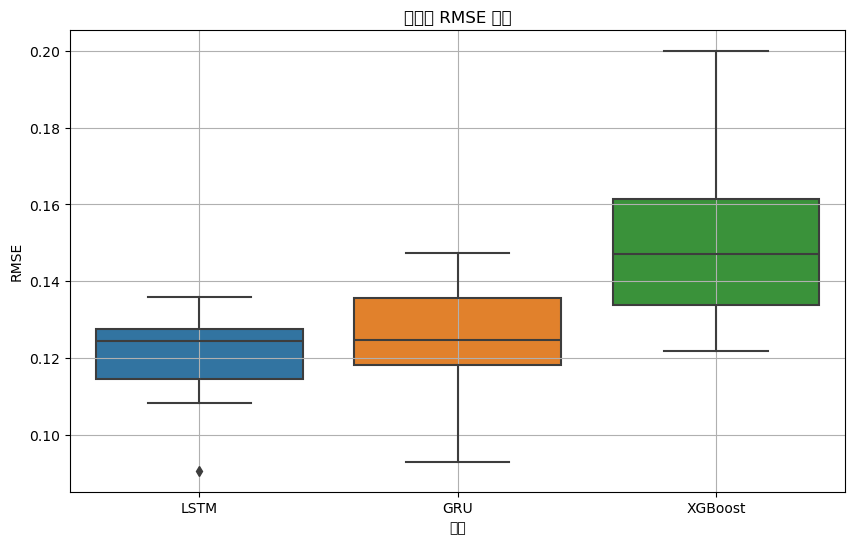

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x='모델', y='RMSE')
plt.title("모델별 RMSE 분포")
plt.ylabel("RMSE")
plt.xlabel("모델")
plt.grid(True)
plt.show()

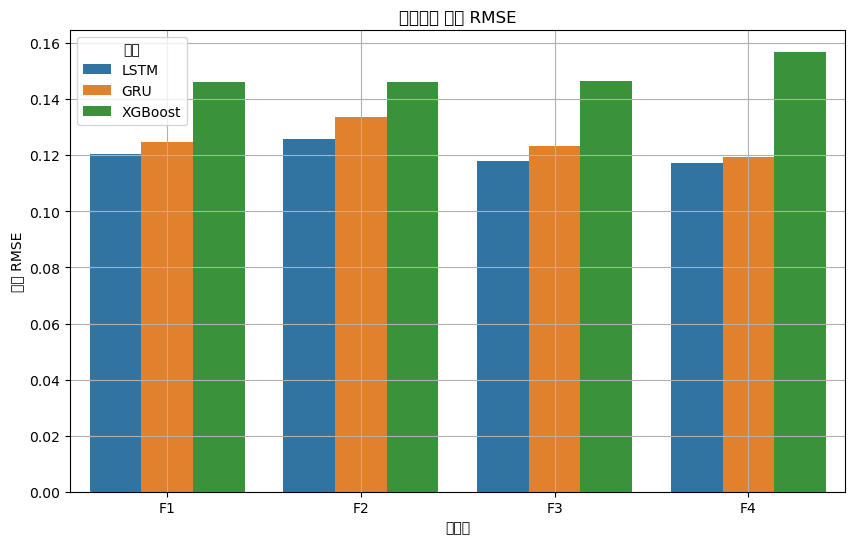

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='피처조합', y='RMSE', hue='모델', ci=None)
plt.title("피처셋별 평균 RMSE")
plt.ylabel("평균 RMSE")
plt.xlabel("피처셋")
plt.grid(True)
plt.show()

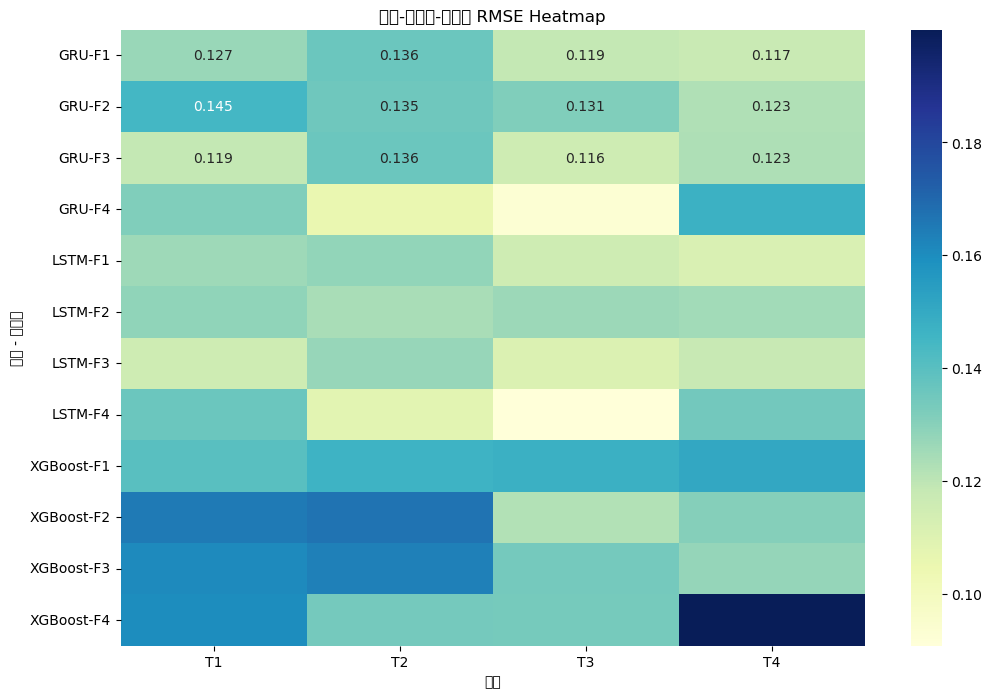

In [23]:
pivot_table = results_df.pivot_table(index=['모델', '피처조합'], columns='타겟', values='RMSE')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("모델-피처셋-타겟별 RMSE Heatmap")
plt.ylabel("모델 - 피처셋")
plt.xlabel("타겟")
plt.show()

rmse 값을 통해 전반적으로 XGBoost에서 값이 높고, LSTM에서 값이 낮음을 알 수 있습니다. 이는 전반적인 성능이 XGBoost가 낮게 작용한다는것을 시각화를 통해 알 수 있었습니다.

# R² 시각화

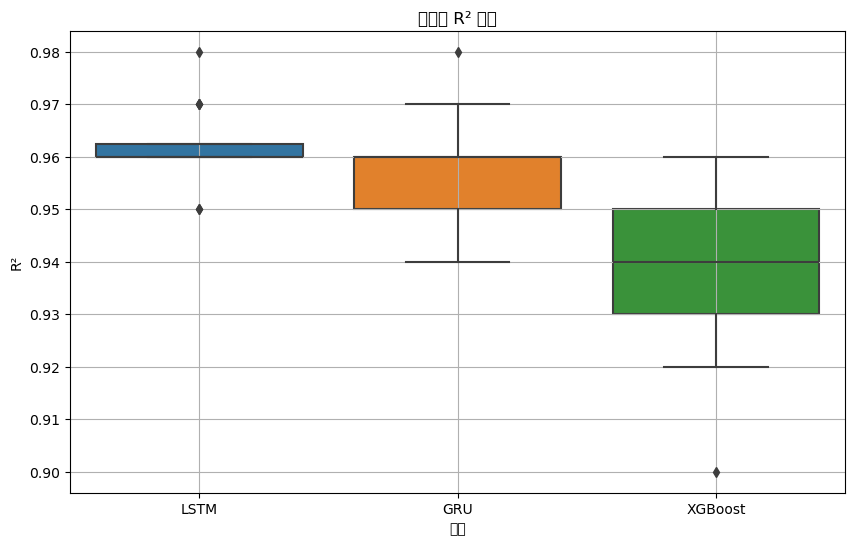

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x='모델', y='R²')
plt.title("모델별 R² 분포")
plt.ylabel("R²")
plt.xlabel("모델")
plt.grid(True)
plt.show()

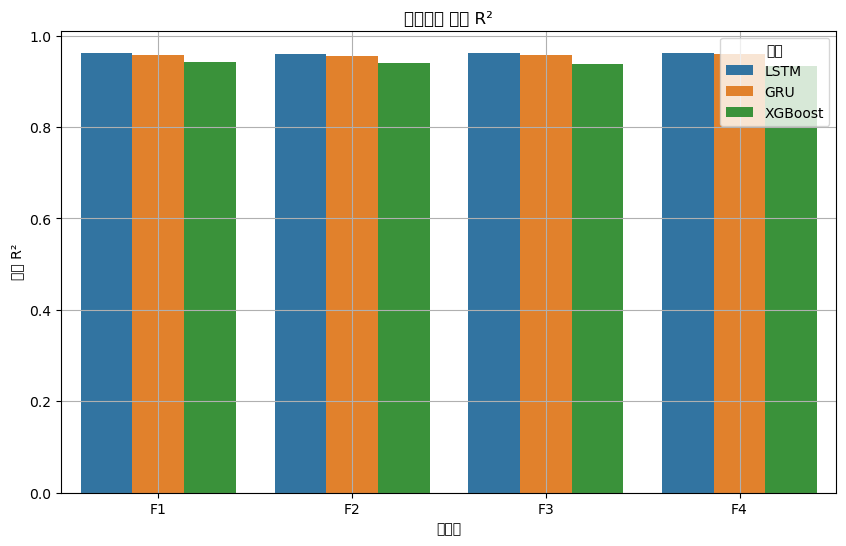

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='피처조합', y='R²', hue='모델', ci=None)
plt.title("피처셋별 평균 R²")
plt.ylabel("평균 R²")
plt.xlabel("피처셋")
plt.grid(True)
plt.show()

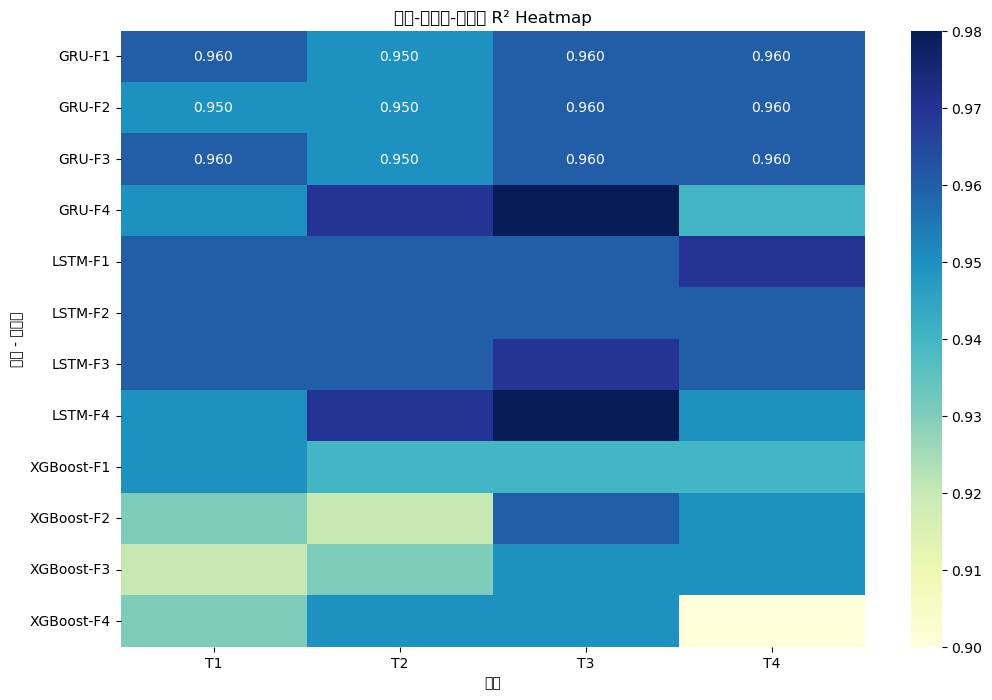

In [26]:
pivot_table = results_df.pivot_table(index=['모델', '피처조합'], columns='타겟', values='R²')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("모델-피처셋-타겟별 R² Heatmap")
plt.ylabel("모델 - 피처셋")
plt.xlabel("타겟")
plt.show()

R^2 값 역시 LSTM에서 가장 높고 XGBoost에서 낮음을 알 수 있었는데 이를 통해서도 위의 RMSE에서의 결과값과 동일한 성능을 알 수 있습니다.

# Directional Accuracy 시각화

/tmp/ipython-input-63-1768346576.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=results_df, x='피처조합', y='Directional Accuracy', hue='모델', ci=None)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

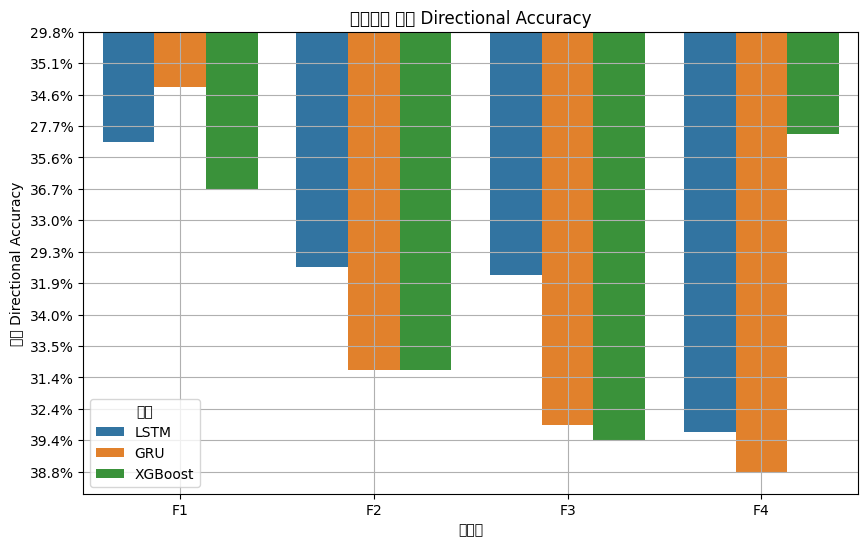

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='피처조합', y='Directional Accuracy', hue='모델', ci=None)
plt.title("피처셋별 평균 Directional Accuracy")
plt.ylabel("평균 Directional Accuracy")
plt.xlabel("피처셋")
plt.grid(True)
plt.show()

정확도 시각화를 통해 보면 위의 시각화 자료를 통해 알 수 있는것과 다른 결과를 알 수 있는데 이는 XGBoost가 결과가 안좋았던것이 모든 경우에서 안 좋아다고 보기보단, 오히려 F1~F3까지의 결과는 가장 좋았던 반면, F4에서는 LSTM과 GRU가 더 나은 결과를 내고 XGBoost의 경우 너무 결과가 안 좋다 보니 평균을 했을때 더 안좋아 보이는 결과가 나타남을 알 수 있습니다.